In [1]:
# ! pip install geojson
# ! pip install gurobipy
# ! -m pip list | grep gurobipy
# ! conda install -c conda-forge pyscipopt
# ! conda update -n base -c defaults conda
# ! pip install pytest
import geojson
from util import *
from shapely import Polygon
from CartogramFramework8 import *

from load_cartogram_data import *

import pandas as pd
# from utils import *

In [2]:
# path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/netherlands/counties.geojson"
path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/netherlands/states.geojson"

# path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/germany/counties.geojson"
# path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/germany/states.geojson"

# path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/usa/counties.geojson"
path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/usa/states.geojson"
# path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/usa/congressional.geojson"
# path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/usa/outline.geojson"

# path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/france/counties.geojson"
# path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/france/states.geojson"

# path_to_file = "/home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/world/world.geojson"


In [3]:
gj = parse_geojson(path_to_file)

In [4]:
def get_all_points(path_to_file, verbose=False):
    gj = parse_geojson(path_to_file)
    points = {}
    for feature in gj['features']:
        # normalize MultiPolygon → largest Polygon first
        # feature = largest_polygon(feature)
        name = feature['properties']['name']
        coords = feature['geometry']['coordinates'][0]  # outer ring
        if verbose:
            print(feature)
            print(name)
        points[name] = coords
    return points

In [5]:
print(get_all_points(path_to_file, verbose=False))

{'Alabama': [[-87.359296, 35.00118], [-85.606675, 34.984749], [-85.431413, 34.124869], [-85.184951, 32.859696], [-85.069935, 32.580372], [-84.960397, 32.421541], [-85.004212, 32.322956], [-84.889196, 32.262709], [-85.058981, 32.13674], [-85.053504, 32.01077], [-85.141136, 31.840985], [-85.042551, 31.539753], [-85.113751, 31.27686], [-85.004212, 31.003013], [-85.497137, 30.997536], [-87.600282, 30.997536], [-87.633143, 30.86609], [-87.408589, 30.674397], [-87.446927, 30.510088], [-87.37025, 30.427934], [-87.518128, 30.280057], [-87.655051, 30.247195], [-87.90699, 30.411504], [-87.934375, 30.657966], [-88.011052, 30.685351], [-88.10416, 30.499135], [-88.137022, 30.318396], [-88.394438, 30.367688], [-88.471115, 31.895754], [-88.241084, 33.796253], [-88.098683, 34.891641], [-88.202745, 34.995703], [-87.359296, 35.00118]], 'Alaska': [[[-131.602021, 55.117982], [-131.569159, 55.28229], [-131.355558, 55.183705], [-131.38842, 55.01392], [-131.645836, 55.035827], [-131.602021, 55.117982]]], 'Ar

In [6]:
df = pd.read_csv("/home/kuenem/Documents/development/lectures/Master Thesis/data/statistics/USA/nst-est2016-01.csv")


In [7]:
print(df.iloc[:, 0].head(20).tolist())

['Table 1. Annual Estimates of the Resident Population for the United States, Regions, States, and Puerto Rico: April 1, 2010 to July 1, 2016', 'Geographic Area', nan, 'United States', 'Northeast', 'Midwest', 'South', 'West', '.Alabama', '.Alaska', '.Arizona', '.Arkansas', '.California', '.Colorado', '.Connecticut', '.Delaware', '.District of Columbia', '.Florida', '.Georgia', '.Hawaii']


In [8]:
polygon = []
target_areas = [] # [0.2, 0.2, 0.3, 0.2, 0.1, 0.4, 0.3, 0.2, 0.1, 0.2, 0.3, 0.4]
# for points in get_all_points(path_to_file, verbose=False).values():
#     target_areas.append(Polygon(points).area)
target_positions = []
names = []
centroid = []
# for name, points in get_all_points(path_to_file, verbose=False).items():
#     names.append(name)
#     print(f"{name} area: {Polygon(points).area}")
#     rdp_points = points # rdp_target(points, 100)
#     polygon.append(rdp_points)
#     target_positions.append(np.mean(rdp_points, axis=0) + [10, 10])
#     centroid.append((10.187972, 51.314139))
#     # names.append(name)
#     # print(np.mean(rdp_points, axis=0))
#     # 51° 18' 50,9"N 10° 11' 16,7"E

points_dict = get_all_points(path_to_file, verbose=False)

for name, points in points_dict.items():
    names.append(name)
    print(f"{name}: {get_value(df, name, "2016")}")
    print(type(get_value(df, name, "2016")))
    target_areas.append(float(get_value(df, name, "2016").replace(",", "")))
    # area = Polygon(points).area
    # target_areas.append(area)
    # print(f"{name} area: {area}")
    rdp_points = points
    polygon.append(rdp_points)
    target_positions.append(np.mean(rdp_points, axis=0) + [10, 10])
    centroid.append((10.187972, 51.314139))

Alabama: 4,863,300
<class 'str'>
Alaska: 741,894
<class 'str'>
Arizona: 6,931,071
<class 'str'>
Arkansas: 2,988,248
<class 'str'>
California: 39,250,017
<class 'str'>
Colorado: 5,540,545
<class 'str'>
Connecticut: 3,576,452
<class 'str'>
Delaware: 952,065
<class 'str'>
District of Columbia: 681,170
<class 'str'>
Florida: 20,612,439
<class 'str'>
Georgia: 10,310,371
<class 'str'>
Hawaii: 1,428,557
<class 'str'>
Idaho: 1,683,140
<class 'str'>
Illinois: 12,801,539
<class 'str'>
Indiana: 6,633,053
<class 'str'>
Iowa: 3,134,693
<class 'str'>
Kansas: 2,907,289
<class 'str'>
Kentucky: 4,436,974
<class 'str'>
Louisiana: 4,681,666
<class 'str'>
Maine: 1,331,479
<class 'str'>
Maryland: 6,016,447
<class 'str'>
Massachusetts: 6,811,779
<class 'str'>
Michigan: 9,928,300
<class 'str'>
Minnesota: 5,519,952
<class 'str'>
Mississippi: 2,988,726
<class 'str'>
Missouri: 6,093,000
<class 'str'>
Montana: 1,042,520
<class 'str'>
Nebraska: 1,907,116
<class 'str'>
Nevada: 2,940,058
<class 'str'>
New Hampshire

In [9]:
gj = parse_geojson(path_to_file)
for f in gj['features']:
    name = f['properties']['name']
    if name in ['California', 'Texas', 'Washington']:
        coords = f['geometry']['coordinates']
        print(f"{name}: {len(coords)} rings, outer ring has {len(coords[0])} points")
        print(f"  first point: {coords[0][0]}")
        print(f"  geometry type: {f['geometry']['type']}")

California: 1 rings, outer ring has 93 points
  first point: [-123.233256, 42.006186]
  geometry type: Polygon
Texas: 1 rings, outer ring has 152 points
  first point: [-101.812942, 36.501861]
  geometry type: Polygon
Washington: 3 rings, outer ring has 1 points
  first point: [[-117.033359, 49.000239], [-117.044313, 47.762451], [-117.038836, 46.426077], [-117.055267, 46.343923], [-116.92382, 46.168661], [-116.918344, 45.993399], [-118.988627, 45.998876], [-119.125551, 45.933153], [-119.525367, 45.911245], [-119.963522, 45.823614], [-120.209985, 45.725029], [-120.505739, 45.697644], [-120.637186, 45.746937], [-121.18488, 45.604536], [-121.217742, 45.670259], [-121.535404, 45.725029], [-121.809251, 45.708598], [-122.247407, 45.549767], [-122.762239, 45.659305], [-122.811531, 45.960537], [-122.904639, 46.08103], [-123.11824, 46.185092], [-123.211348, 46.174138], [-123.370179, 46.146753], [-123.545441, 46.261769], [-123.72618, 46.300108], [-123.874058, 46.239861], [-124.065751, 46.327492]

In [10]:
p = []
for name, pts in zip(names, polygon):
    # print(name)
    # print(pts)
    # print(len(pts))
    for poly in pts:
        if len(poly) != 2:
            print(len(poly))
            if len(pts) == 1:
                pts = pts[0]
    p.append(pts)
polygon = p

6
18
4
64
4
65
61


In [11]:
from shapely.geometry import Polygon as ShapelyPolygon

exclude = {'Alaska', 'Hawaii', 'Puerto Rico'}
print(type(exclude))

filtered = [(name, pts, trgt_rs) for name, pts, trgt_rs in zip(names, polygon, target_areas) if name not in exclude]
names = [n for n, _, _ in filtered]
polygon = [p for _, p, _ in filtered]
target_areas = [trgt_rs for _, _, trgt_rs in filtered]

<class 'set'>


In [12]:
gj = parse_geojson(path_to_file)
for f in gj['features']:
    name = f['properties']['name']
    if name in exclude:
        continue
    if f['geometry']['type'] == 'MultiPolygon':
        sizes = [len(poly[0]) for poly in f['geometry']['coordinates']]
        print(f"{name}: {sizes}")

Maryland: [4, 60]
Michigan: [64, 5, 76, 7]
Rhode Island: [4, 11]
Virginia: [65, 11]
Washington: [61, 5, 6]


In [13]:
gj = parse_geojson(path_to_file)
for f in gj['features']:
    name = f['properties']['name']
    result = largest_polygon(f)
    print(name, result['geometry']['type'])

Alabama Polygon
Alaska Polygon
Arizona Polygon
Arkansas Polygon
California Polygon
Colorado Polygon
Connecticut Polygon
Delaware Polygon
District of Columbia Polygon
Florida Polygon
Georgia Polygon
Hawaii Polygon
Idaho Polygon
Illinois Polygon
Indiana Polygon
Iowa Polygon
Kansas Polygon
Kentucky Polygon
Louisiana Polygon
Maine Polygon
Maryland Polygon
Massachusetts Polygon
Michigan Polygon
Minnesota Polygon
Mississippi Polygon
Missouri Polygon
Montana Polygon
Nebraska Polygon
Nevada Polygon
New Hampshire Polygon
New Jersey Polygon
New Mexico Polygon
New York Polygon
North Carolina Polygon
North Dakota Polygon
Ohio Polygon
Oklahoma Polygon
Oregon Polygon
Pennsylvania Polygon
Rhode Island Polygon
South Carolina Polygon
South Dakota Polygon
Tennessee Polygon
Texas Polygon
Utah Polygon
Vermont Polygon
Virginia Polygon
Washington Polygon
West Virginia Polygon
Wisconsin Polygon
Wyoming Polygon
Puerto Rico Polygon


In [14]:
import sys

# Example: USA states population 2016 (requires files to exist)
try:
    polygon, target_areas, target_positions, names, centroid = load_cartogram_data(
        country="USA",
        detail="states",
        data_type="population",
        year=2016, # np.int64(2020),
        geojson_dir="data/geojson",
        data_dir="data/statistics",
        verbose=True,
    )
    print(f"\nResult: {len(names)} regions")
    print(f"First 5 names:  {names[:5]}")
    print(f"First 5 areas:  {target_areas[:5]}")
    print(f"First position: {target_positions[0]}")
    print(f"First centroid: {centroid[0]}")
except FileNotFoundError as e:
    print(f"[Expected during test — files not present] {e}", file=sys.stderr)

GeoJSON loaded: /home/kuenem/Documents/development/lectures/Master Thesis/data/geojson/usa/states.geojson  (52 features)
  Stat data loaded: 51 rows
  Excluding: Alaska
  Excluding: Hawaii


  Excluding: Puerto Rico
Loaded 49 regions.

Result: 49 regions
First 5 names:  ['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado']
First 5 areas:  [4863300.0, 6931071.0, 2988248.0, 39250017.0, 5540545.0]
First position: [np.float64(-86.69426293939391), np.float64(31.96629081818182)]
First centroid: (-86.82778271419518, 32.78990682135675)


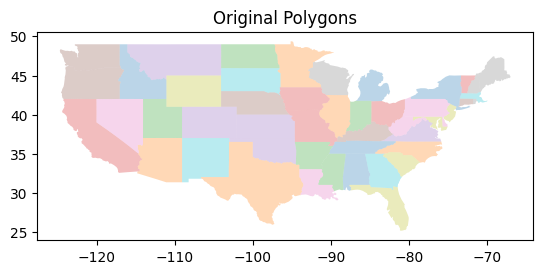

In [15]:
plot_polys(polygon, title="Original Polygons", legend=False)

In [16]:
polygons = polygon
horizontal_pairs, vertical_pairs = disjoint_pairs_horizontal_and_vertical_center(polygons)

In [17]:
print(f"Horizontal pairs: {horizontal_pairs}")
print(f"Vertical pairs: {vertical_pairs}")

Horizontal pairs: [(1, 0), (2, 0), (3, 0), (4, 0), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (10, 0), (14, 0), (16, 0), (0, 17), (0, 18), (0, 19), (22, 0), (24, 0), (25, 0), (26, 0), (0, 27), (0, 28), (29, 0), (0, 30), (0, 31), (34, 0), (35, 0), (0, 36), (0, 37), (0, 38), (39, 0), (41, 0), (42, 0), (0, 43), (0, 44), (45, 0), (48, 0), (1, 2), (3, 1), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19), (1, 20), (1, 21), (1, 22), (1, 23), (1, 25), (1, 27), (1, 28), (1, 29), (1, 30), (1, 31), (1, 32), (1, 33), (1, 34), (1, 36), (1, 37), (1, 38), (1, 39), (1, 40), (1, 41), (1, 43), (1, 44), (1, 46), (1, 47), (3, 2), (4, 2), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (10, 2), (2, 12), (14, 2), (2, 15), (2, 17), (2, 18), (2, 19), (24, 2), (26, 2), (2, 27), (2, 28), (29, 2), (2, 30), (2, 31), (2, 33), (34, 2), (35, 2), (2, 36), (2, 37), (2, 38), (2, 40), (41, 2), (42, 2), (2, 43), (2, 44), (45, 2), (2, 46), (48, 2), (3, 4)

# Function Calls

## Demer

In [18]:

# new_polys_sq, areas_sq, status_sq, val_sq, leaders_sq, t_areas_sq = \
#     CartogramFramework_global(
#         polygons        = polygons,
#         target_areas    = target_areas_raw,
#         shape           = "square",
#         horizontal_pairs=horizontal_pairs,
#         vertical_pairs=vertical_pairs,
#         neighboring_pairs = nbr_pairs,
#         lambda_shape    = 0.1,
#         lambda_area     = 1.0,
#         lambda_center   = 0.0,
#         lambda_topology = 1.0,
#         gamma           = 0.0,

#         beta=1.0,
#         alpha=1.0,
#         epsilon=1e-2,
#         b=1e-2,
#         t_min=0.01,
#         shape_deformation=0.0,  # triggers make_square() until patch is applied
#     )

/home/kuenem/miniconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/kuenem/miniconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Contiguous mode 'square': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 96.4476


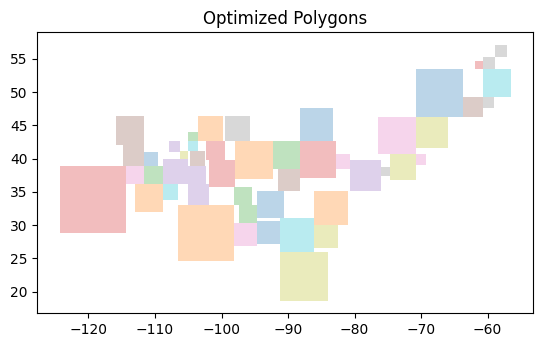

In [19]:
new_polys, areas, status, val, leaders, target_areas = \
    CartogramFramework_global(
        polygons=polygons,
        target_areas=target_areas,
        fixed_points=None,             # → uses polygon centroids as origins
        shape="square",             # "circle", "square", or "contiguous"
        target_centers=target_positions,
        horizontal_pairs=horizontal_pairs,
        vertical_pairs=vertical_pairs,
        neighboring_pairs=neighbouring_pairs(polygons),
        shared_vertices_of_neighbors=shared_vertices_of_neighbors(polygons),

        lambda_shape=0.1,    # small; E_square ≈ 0 once squares are pre-built # Demers: 0.1
        lambda_area=1.0,      # Demers 1.0
        lambda_center=0.0,    # TOP variant (Fig. 1 left) — purely minimise gaps # Demers: 0,0
        lambda_topology=1.0,  # paper's objective (1): min Σ h_ij + v_ij # Demers: 1.0

        gamma=0.0,            # pure E_square — REQUIRED for Demers
        beta=1.0,
        alpha=1.0,
        epsilon=1e-2,
        b=1e-2,
        t_min=0.01,
        shape_deformation=0.0,  # triggers make_square() until patch is applied
    )
plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

## Dorling

Contiguous mode 'circle': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 664.419


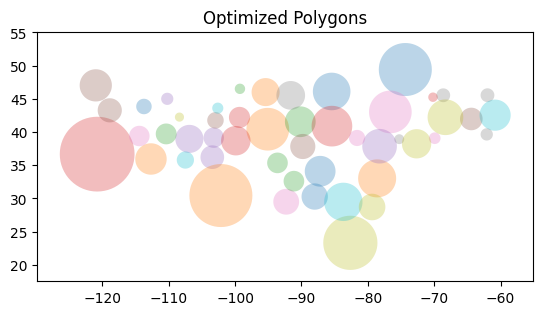

In [20]:
new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
    polygons        = polygons,
    target_areas    = target_areas,
    fixed_points    = None,
    shape           = "circle",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors=shared_vertices_of_neighbors(polygons),

    lambda_shape    = 0.1,   # small — circles form without needing shape pressure
    lambda_area     = 1.0,
    lambda_center   = 0.5,   # moderate centre fidelity keeps circles near geography
    lambda_topology = 1.0,

    gamma = 0.0,   # REQUIRED — pure E_circle
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,
    t_min   = 0.01,
    t_max   = 5.0,
    shape_deformation = 0.0,   # triggers make_circle()
)
plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

## Contiguous

Contiguous mode 'contiguous2': 844 shared-vertex penalty terms added.


/home/kuenem/Documents/development/lectures/Master Thesis/Test/Geometry/CartogramFramework8.py:966: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  prob = cp.Problem(objective, constraints)


Status : optimal
Obj val: 669301
Post-processing: snapping shared vertices (method='mean', shrink=1)…


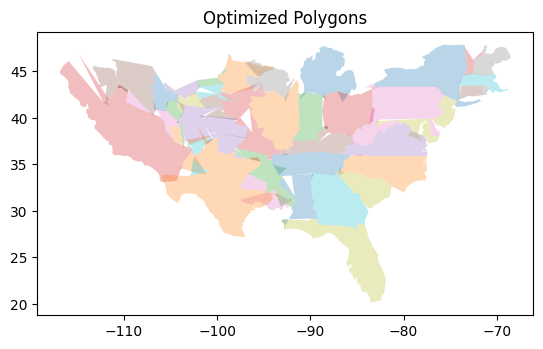

In [ ]:
new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
    polygons        = polygons,
    target_areas    = target_areas,
    fixed_points    = None,
    shape           = "contiguous2",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

    lambda_shape      = 0.5,
    lambda_area       = 1.0,
    lambda_center     = 0.0,
    lambda_topology   = 0.0,
    lambda_contiguous = 80.0,
    soft_mean_scale   = True,
    lambda_mean_scale = 1e4,
    t_min = 0.01,
    t_max = 1.5,
    lambda_vertex_distance = 10.0,
    vertex_distance_margin = 1.5,
    lambda_repulsion  = 0.0,
    contiguous_area_ratio_cap = np.inf,
    contiguous_use_topology   = False,
    gamma = 1.0,
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,

    # ── Post-processing ───────────────────────────────────────────
    postprocess_contiguous  = True,     # flip to False to skip entirely
    postprocess_snap_method = "mean",   # midpoint snap on shared vertices
)
plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

## Non-Contiguous

Contiguous mode 'original': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 1448.75


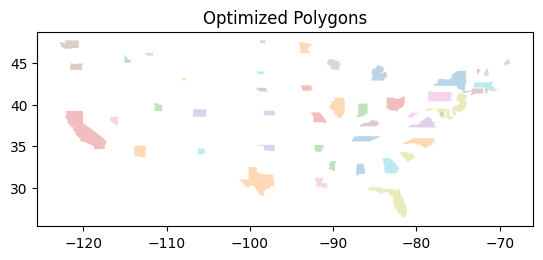

In [22]:
new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
    polygons         = polygons,
    target_areas     = target_areas,
    fixed_points     = None,
    shape            = "original",
    target_centers   = target_positions,
    horizontal_pairs = None,   # no ordering — just scale in place
    vertical_pairs   = None,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = None,

    lambda_shape    = 1.0,
    lambda_area     = 1.0,
    lambda_center   = 0.5,   # moderate pull keeps regions near original position
    lambda_topology = 0.0,   # OFF — ordering was causing infeasibility

    area_scale = 0.1,

    gamma = 1.0,
    beta  = 1.0,
    t_min = 0.01,
    t_max = 25.0,   # large — some regions may need to grow a lot
)
plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

# Experiments


## Anchor Dorling

Contiguous mode 'circle': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 115.993


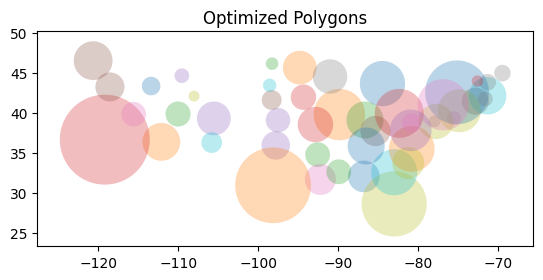

In [23]:
new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
    polygons         = polygons,
    target_areas     = target_areas,
    fixed_points     = None,
    shape            = "circle",
    target_centers   = target_positions,   # must differ from centroids to have effect
    horizontal_pairs = None,   # circles need no ordering direction
    vertical_pairs   = None,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = None,

    lambda_shape    = 0.05,
    lambda_area     = 1.0,
    lambda_center   = 0.3,   # light tether — enough to stay near geography
    lambda_topology = 0.8,   # topology drives circle packing

    gamma = 0.0,
    t_min = 0.01,
    t_max = 5.0,
    shape_deformation = 0.0,
)
plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

## Soft Demers

Contiguous mode 'square': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 144.671


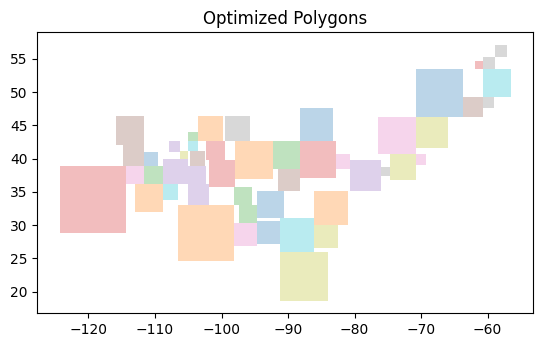

In [24]:

new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
    polygons         = polygons,
    target_areas     = target_areas,   # must differ from polygon_areanp(p) for each p
    fixed_points     = None,
    shape            = "square",
    target_centers   = target_positions,
    horizontal_pairs = horizontal_pairs,   # _center variant — critical for Demers
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = None,

    lambda_shape    = 0.1,
    lambda_area     = 1.0,
    lambda_center   = 0.0,   # off — target_positions==centroids so term is zero anyway
    lambda_topology = 1.5,   # slightly higher than standard Demers for tighter packing

    gamma = 0.0,
    t_min = 0.01,
    t_max = 5.0,
    shape_deformation = 0.0,
)
plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

## L2 smooth non-contiguous

Contiguous mode 'original': 0 shared-vertex penalty terms added.
Status : infeasible
Obj val: inf
  Tips for contiguous mode:
    • Raise contiguous_area_ratio_cap (skips locking large-ratio pairs)
    • Set contiguous_use_topology=False to drop topology terms
    • Switch to shape='contiguous2' (soft penalty instead of hard equality)


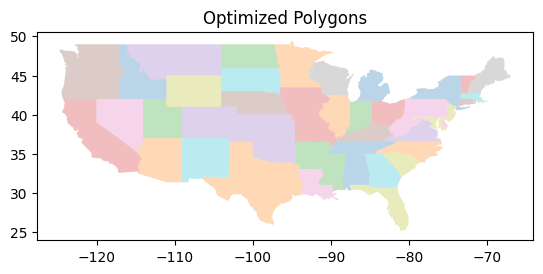

In [25]:
new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
    polygons         = polygons,
    target_areas     = target_areas,
    fixed_points     = None,
    shape            = "original",
    target_centers   = target_positions,
    horizontal_pairs = horizontal_pairs,   # was missing — now added
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = None,

    lambda_shape    = 1.0,
    lambda_area     = 1.0,
    lambda_center   = 0.0,
    lambda_topology = 1.0,

    gamma = 0.5,   # blend deformation + shape pressure
    beta  = 0.0,   # L2: smooth, rounded deformation
    t_min = 0.01,
    t_max = 5.0,
)
plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

## Topology-first non-contiguous

Contiguous mode 'original': 0 shared-vertex penalty terms added.
Status : infeasible
Obj val: inf
  Tips for contiguous mode:
    • Raise contiguous_area_ratio_cap (skips locking large-ratio pairs)
    • Set contiguous_use_topology=False to drop topology terms
    • Switch to shape='contiguous2' (soft penalty instead of hard equality)


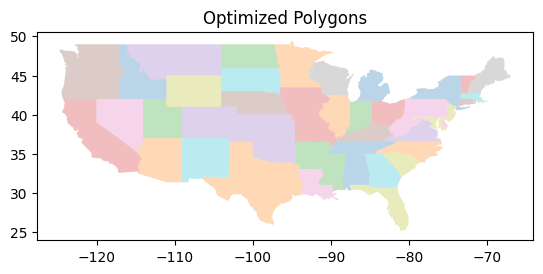

In [26]:
new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
    polygons         = polygons,
    target_areas     = target_areas,
    fixed_points     = None,
    shape            = "original",
    target_centers   = target_positions,
    horizontal_pairs = horizontal_pairs,   # _center: fewer, cleaner pairs
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = None,

    lambda_shape    = 0.1,
    lambda_area     = 1.0,
    lambda_center   = 0.3,   # light geographic anchor — helps solver find feasible point
    lambda_topology = 2.0,   # dominant but not 5× — 5 caused geometric infeasibility

    gamma = 1.0,
    beta  = 1.0,
    t_min = 0.01,
    t_max = 8.0,
    epsilon = 0.0,   # adjacent states may touch — critical for feasibility
)
plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

## Contiguous + geographic centre fidelity

Contiguous mode 'contiguous2': 844 shared-vertex penalty terms added.
Status : optimal
Obj val: 439540


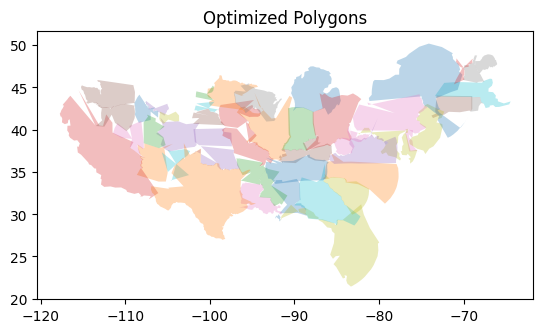

In [27]:
new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
    polygons         = polygons,
    target_areas     = target_areas,
    fixed_points     = None,
    shape            = "contiguous2",
    # Pass population-weighted centres if you have them; otherwise None lets
    # the contiguous + area terms drive movement without a centre pull.
    target_centers   = target_positions,   # only has effect if != centroids
    horizontal_pairs = None,
    vertical_pairs   = None,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

    lambda_shape      = 1.0,
    lambda_area       = 1.0,
    lambda_center     = 0.2,   # light — only meaningful if target_centers != centroids
    lambda_topology   = 0.0,

    lambda_contiguous      = 80.0,
    soft_mean_scale        = True,
    lambda_mean_scale      = 1e4,
    t_min = 0.01,
    t_max = 2.5,
    lambda_vertex_distance = 10.0,
    vertex_distance_margin = 1.5,
    lambda_repulsion       = 0.0,
    contiguous_area_ratio_cap = np.inf,
    contiguous_use_topology   = False,
    gamma = 1.0,
    beta  = 1.0,
)
plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

## Hybrid Demers-contiguous 

Contiguous mode 'square': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 48.2238


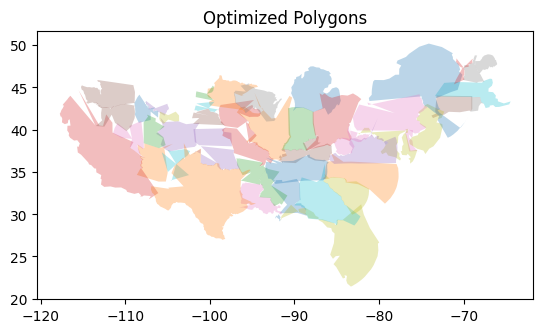

In [28]:
CartogramFramework_global(
    polygons        = polygons,
    target_areas    = target_areas,
    shape = "square",          # E_square target
    lambda_shape     = 0.1,
    lambda_area      = 1.0,
    lambda_center    = 0.0,
    lambda_topology  = 0.5,
    lambda_contiguous = 20.0,  # moderate — squares can't fully share vertices
    soft_mean_scale   = True,
    lambda_mean_scale = 1e4,
    t_min = 0.01,
    t_max = 3.0,
    lambda_vertex_distance = 5.0,
    vertex_distance_margin = 2.0,  # looser — squares have extreme vertices
    contiguous_area_ratio_cap = 5.0,
    contiguous_use_topology   = False,
    gamma = 0.0,   # pure E_square
    shape_deformation = 0.0,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),
)
plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

## Main Cartogram types
Choose between Demers, Dorling or Contiguous as base setting

In [29]:
Cartogram = "Demers"
if Cartogram == "Manual":
    shape="original"
    lambda_shape=1.0     # small; E_square ≈ 0 once squares are pre-built # Demers: 0.1
    lambda_area=5.0      # Demers 1.0
    lambda_center=0.5    # TOP variant (Fig. 1 left) — purely minimise gaps # Demers: 0,0
    lambda_topology=0.0  # paper's objective (1): min Σ h_ij + v_ij # Demers: 1.0

    gamma=0.0            # pure E_square — REQUIRED for Demers
    beta=1.0
    alpha=1.0
    epsilon=1e-2
    b=1e-2
    t_min=0.01
    shape_deformation=0.0  # triggers make_square() until patch is applied
if Cartogram == "Demers": 
    shape="square"
    lambda_shape=0.1     # small; E_square ≈ 0 once squares are pre-built # Demers: 0.1
    lambda_area=1.0      # Demers 1.0
    lambda_center=0.0    # TOP variant (Fig. 1 left) — purely minimise gaps # Demers: 0,0
    lambda_topology=1.0  # paper's objective (1): min Σ h_ij + v_ij # Demers: 1.0

    gamma=0.0            # pure E_square — REQUIRED for Demers
    beta=1.0
    alpha=1.0
    epsilon=1e-2
    b=1e-2
    t_min=0.01
    shape_deformation=0.0  # triggers make_square() until patch is applied
if Cartogram == "Contiguous":
    shape="contiguous"
    lambda_shape=1.0     # small; E_square ≈ 0 once squares are pre-built # Demers: 0.1
    lambda_area=5.0      # Demers 1.0
    lambda_center=0.5    # TOP variant (Fig. 1 left) — purely minimise gaps # Demers: 0,0
    lambda_topology=0.0  # paper's objective (1): min Σ h_ij + v_ij # Demers: 1.0

    gamma=0.0            # pure E_square — REQUIRED for Demers
    beta=1.0
    alpha=1.0
    epsilon=1e-2
    b=1e-2
    t_min=0.01
    shape_deformation=0.0  # triggers make_square() until patch is applied


In [30]:
polygons = polygon
horizontal_pairs, vertical_pairs = disjoint_pairs_horizontal_and_vertical_center(polygons)

new_polys, areas, problem_status, problem_value, leaders, target_areas_norm = \
    CartogramFramework_global(
        polygons=polygons,
        target_areas=target_areas,
        fixed_points=None,             # → uses polygon centroids as origins
        shape=shape,             # "circle", "square", or "contiguous"
        target_centers=target_positions,
        horizontal_pairs=horizontal_pairs,
        vertical_pairs=vertical_pairs,
        neighboring_pairs=neighbouring_pairs(polygons),
        shared_vertices_of_neighbors=shared_vertices_of_neighbors(polygons),

        lambda_shape=lambda_shape,     # small; E_square ≈ 0 once squares are pre-built # Demers: 0.1
        lambda_area=lambda_area,      # Demers 1.0
        lambda_center=lambda_center,    # TOP variant (Fig. 1 left) — purely minimise gaps # Demers: 0,0
        lambda_topology=lambda_topology,  # paper's objective (1): min Σ h_ij + v_ij # Demers: 1.0

        gamma=gamma,            # pure E_square — REQUIRED for Demers
        beta=beta,
        alpha=alpha,
        epsilon=epsilon,
        b=b,
        t_min=t_min,
        shape_deformation=shape_deformation,  # triggers make_square() until patch is applied
    )
plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None, names=None)
# for a, b in zip(target_areas_norm, areas):
#     print(a, b)
#     print(a - b)

Contiguous mode 'square': 0 shared-vertex penalty terms added.


KeyboardInterrupt: 

# Approach 1 — unlocks t_max without infeasibility
    soft_mean_scale   = True, standard False
    lambda_mean_scale = 1e4, standard 1e4
    t_min = 0.01,
    t_max = 2.5,       # can now be tight since mean-scale is soft

    # Approach 3 — directly kills spikes beyond 1.5× ideal radius
    lambda_vertex_distance  = 10.0, standard 0.0
    vertex_distance_margin  = 1.5, standard 1.5

    # Approach 2 — optional, helps if centres collapse
    lambda_repulsion   = 0.5, standard 0.0
    repulsion_margin   = 3.0,   # ~3° for US states standard 1.0
    repulsion_only_adjacent = False, standard False

Contiguous mode 'contiguous2': 844 shared-vertex penalty terms added.


/home/kuenem/Documents/development/lectures/Master Thesis/Test/Geometry/CartogramFramework8.py:967: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  prob.solve(solver=cp.CLARABEL, verbose=False)


Status : optimal
Obj val: 32590


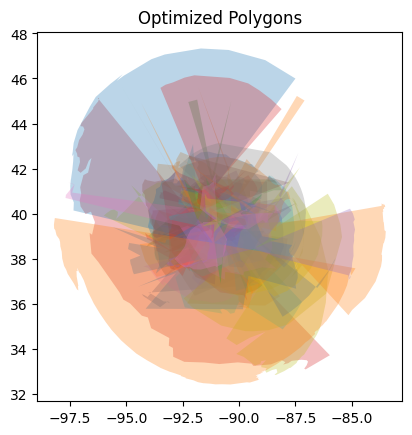

[6.681474617063941, 8.305598387421924, 3.4105680192587897, 55.33457197571988, 10.77365399230257, 8.488963083698764, 0.22286653309492976, 0.48385937121383904, 10.55740696277644, 21.001859653013526, 0.9869127898127772, 22.157055376039352, 9.293584802624537, 8.697363571351161, 2.3862181273507304, 10.406356469437014, 8.870843461816548, 2.512179868048406, 6.157554089295445, 9.909150244478951, 19.7431050924788, 9.869944971636869, 4.7899862930353265, 9.87201529898448, 2.4802652228972875, 3.2332899660978, 3.8200823925144505, 2.5616063111956464, 23.234557460687938, 4.330212690823828, 62.2656660136272, 24.184683584229788, 0.4624872224048886, 22.096460433473112, 2.1240655010333285, 8.726546992606018, 12.513936704184744, 2.0105889534024755, 11.74728804161714, 1.7209565106095397, 19.942733223113464, 61.124311190797016, 2.7935721725989424, 1.485145753766119, 13.823237898453954, 10.96742001583334, 5.3411888016999, 16.755077061796328, 1.266097353432997]


In [ ]:
polygons = polygon
horizontal_pairs, vertical_pairs = disjoint_pairs_horizontal_and_vertical(polygons)
new_polys, areas, problem_status, problem_value, leaders, target_areas = CartogramFramework_global(
    polygons=polygons,
    target_areas=target_areas,
    fixed_points=None,
    shape="contiguous2",
    target_centers=target_positions,
    horizontal_pairs=horizontal_pairs,
    vertical_pairs=vertical_pairs,
    neighboring_pairs=neighbouring_pairs(polygons),
    shared_vertices_of_neighbors=shared_vertices_of_neighbors(polygons),
    # objective weights (λ in the paper)
    lambda_shape=1.0,       # λ_s: shape deformation weight
    lambda_area=1.0,        # λ_a: cartographic error weight
    lambda_center=0.0,      # λ_c: centre fidelity (spatial deformation)
    lambda_topology=0.0,    # λ_t: pairwise topology weight
    lambda_contiguous = 50.0,


    # Approach 1 — unlocks t_max without infeasibility
    soft_mean_scale   = False,
    lambda_mean_scale = 1e4,
    t_min = 0.01,
    t_max = 25,       # can be tight if soft_mean_scale is true, but may cause infeasibility if false (since mean-scale is hard)

    # Approach 3 — directly kills spikes beyond 1.5× ideal radius
    lambda_vertex_distance  = 10.0,
    vertex_distance_margin  = 1.5,

    # Approach 2 — optional, helps if centres collapse
    lambda_repulsion   = 0.5,
    repulsion_margin   = 3.0,   # ~3° for US states
    repulsion_only_adjacent = False,


    contiguous_area_ratio_cap = np.inf,
    contiguous_use_topology = False,
    # shape-term inner parameters
    gamma=1.0,              # blend: 1 = pure deformation, 0 = pure target-shape
    beta=1.0,               # blend: 1 = L1 (z_ik), 0 = L2 ((t-1)^2)
    # misc
    alpha=1.0,
    epsilon=1e-2,
    b=1e-2,
    # t_min=0.01,
    # t_max=25.0, # If too low becomes infeasible, purposed a bit undermined through that
)
plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)
print(areas)

In [ ]:
#  # ------------------------------------------------------------------
# # Minimal toy map: three adjacent rectangles side-by-side
# #
# #   Region 0: x in [0,1], y in [0,1]   — left
# #   Region 1: x in [1,2], y in [0,1]   — centre  (same area as 0)
# #   Region 2: x in [2,3], y in [0,1]   — right   (same area as 0)
# #
# # Shared vertices:
# #   0 & 1 share (1,0) and (1,1)
# #   1 & 2 share (2,0) and (2,1)
# # ------------------------------------------------------------------

# poly0 = np.array([[0,0],[1,0],[1,1],[0,1]], dtype=float)
# poly1 = np.array([[1,0],[2,0],[2,1],[1,1]], dtype=float)
# poly2 = np.array([[2,0],[3,0],[3,1],[2,1]], dtype=float)
# # polygons = [poly0, poly1, poly2]

# # Target areas: double the middle region
# original_areas = [polygon_areanp(p) for p in polygons]
# target_areas_raw = target_areas # [original_areas[0], 2.0 * original_areas[1], original_areas[2]]

# # Compute adjacency and shared vertices
# nbr_pairs  = neighbouring_pairs(polygons)
# sv_data    = shared_vertices_of_neighbors(polygons)

# print("Neighbouring pairs:", nbr_pairs)
# for entry in sv_data:
#     print(f"  Regions {entry[0]}-{entry[1]} share vertices: {entry[2]}")
# horizontal_pairs, vertical_pairs = disjoint_pairs_horizontal_and_vertical_center(polygons)


# centers = [np.mean(p, axis=0) for p in polygons]

# plot_polys(polygons, title="Original Polygons", centroids=centers, legend=False, target_centers=None)

# # ------------------------------------------------------------------
# # 1. Original (baseline — no contiguous constraint)
# # ------------------------------------------------------------------
# print("\n" + "="*60)
# print("SHAPE = original")
# new_polys_orig, areas_orig, status, val, leaders, t_areas = \
#     CartogramFramework_global(
#         polygons        = polygons,
#         target_areas    = target_areas_raw,
#         shape           = "original",
#         neighboring_pairs = nbr_pairs,
#         shared_vertices_of_neighbors = sv_data,
#         lambda_shape    = 1.0,
#         lambda_area     = 1.0,
#         lambda_center   = 0.1,
#         lambda_topology = 0.5,
#     )
# for i, (p, a) in enumerate(zip(new_polys_orig, areas_orig)):
#     print(f"  Region {i}: area={a:.4f}  (target={t_areas[i]:.4f})")

# plot_polys(new_polys_orig, title="Original Shape Constraint", centroids=False, legend=False, target_centers=None)

# # ------------------------------------------------------------------
# # 2. Contiguous — hard shared-vertex locking
# # ------------------------------------------------------------------
# print("\n" + "="*60)
# print("SHAPE = contiguous  (hard shared-vertex equality)")
# new_polys_c, areas_c, status_c, val_c, leaders_c, t_areas_c = \
#     CartogramFramework_global(
#         polygons        = polygons,
#         target_areas    = target_areas_raw,
#         shape           = "contiguous",
#         neighboring_pairs = nbr_pairs,
#         shared_vertices_of_neighbors = sv_data,
#         lambda_shape    = 1.0,
#         lambda_area     = 1.0,
#         lambda_center   = 0.1,
#         lambda_topology = 0.5,
#         contiguous_area_ratio_cap = 10.0,   # skip locking if area ratio > 10
#         contiguous_use_topology   = True,
#     )
# for i, (p, a) in enumerate(zip(new_polys_c, areas_c)):
#     print(f"  Region {i}: area={a:.4f}  (target={t_areas_c[i]:.4f})")

# # Verify that shared vertices of the contiguous result actually coincide
# print("  Shared-vertex residuals after hard locking:")
# sv_result = shared_vertices_of_neighbors([p for p in new_polys_c])
# for entry in sv_result:
#     ri, rj, pts = entry[0], entry[1], entry[2]
#     if pts:
#         print(f"    Regions {ri}-{rj}: {len(pts)} shared pts — "
#                 f"max coord diff ≈ {np.max(np.abs(np.array(pts) - np.array(pts))):.2e}")
        
# plot_polys(new_polys_c, title="Contiguous (hard locking)", centroids=False, legend=False, target_centers=None)

# # ------------------------------------------------------------------
# # 3. Contiguous2 — soft shared-vertex penalty
# # ------------------------------------------------------------------
# print("\n" + "="*60)
# print("SHAPE = contiguous2  (soft shared-vertex quadratic penalty)")
# new_polys_c2, areas_c2, status_c2, val_c2, leaders_c2, t_areas_c2 = \
#     CartogramFramework_global(
#         polygons        = polygons,
#         target_areas    = target_areas_raw,
#         shape           = "contiguous2",
#         neighboring_pairs = nbr_pairs,
#         shared_vertices_of_neighbors = sv_data,
#         lambda_shape    = 1.0,
#         lambda_area     = 1.0,
#         lambda_center   = 0.1,
#         lambda_topology = 0.5,
#         lambda_contiguous = 5.0,        # weight of the soft coupling penalty
#         contiguous_use_topology = True,
#     )
# for i, (p, a) in enumerate(zip(new_polys_c2, areas_c2)):
#     print(f"  Region {i}: area={a:.4f}  (target={t_areas_c2[i]:.4f})")

# plot_polys(new_polys_c2, title="Contiguous2 (soft penalty)", centroids=False, legend=False, target_centers=None)

# # ------------------------------------------------------------------
# # 4. Circle (Dorling) — unmodified, sanity check
# # ------------------------------------------------------------------
# print("\n" + "="*60)
# print("SHAPE = circle  (Dorling — existing functionality unchanged)")
# new_polys_circle, areas_circle, status_circ, val_circ, leaders_circ, t_areas_circ = \
#     CartogramFramework_global(
#         polygons        = polygons,
#         target_areas    = target_areas_raw,
#         shape           = "circle",
#         neighboring_pairs = nbr_pairs,
#         lambda_shape    = 0.0,
#         lambda_area     = 1.0,
#         lambda_center   = 0.1,
#         lambda_topology = 0.5,
#         gamma           = 0.0,
#     )
# for i, (p, a) in enumerate(zip(new_polys_circle, areas_circle)):
#     print(f"  Region {i}: area={a:.4f}  (target={t_areas_circ[i]:.4f})")

# plot_polys(new_polys_circle, title="Circle (Dorling)", centroids=False, legend=False, target_centers=None)

# # ------------------------------------------------------------------
# # 5. Square (Demers) — unmodified, sanity check
# # ------------------------------------------------------------------
# print("\n" + "="*60)
# print("SHAPE = square  (Demers — existing functionality unchanged)")
# new_polys_sq, areas_sq, status_sq, val_sq, leaders_sq, t_areas_sq = \
#     CartogramFramework_global(
#         polygons        = polygons,
#         target_areas    = target_areas_raw,
#         shape           = "square",
#         horizontal_pairs=horizontal_pairs,
#         vertical_pairs=vertical_pairs,
#         neighboring_pairs = nbr_pairs,
#         lambda_shape    = 0.1,
#         lambda_area     = 1.0,
#         lambda_center   = 0.0,
#         lambda_topology = 1.0,
#         gamma           = 0.0,

#         beta=1.0,
#         alpha=1.0,
#         epsilon=1e-2,
#         b=1e-2,
#         t_min=0.01,
#         shape_deformation=0.0,  # triggers make_square() until patch is applied
#     )
# for i, (p, a) in enumerate(zip(new_polys_sq, areas_sq)):
#     print(f"  Region {i}: area={a:.4f}  (target={t_areas_sq[i]:.4f})")

# plot_polys(new_polys_sq, title="Square (Demers)", centroids=False, legend=False, target_centers=None)

In [ ]:
# polygons = polygon
# horizontal_pairs, vertical_pairs = disjoint_pairs_horizontal_and_vertical(polygons)
# new_polys, areas, problem_status, problem_value, leaders = CartogramFramework_global(
#     polygons=polygons,
#     target_areas=10,
#     fixed_points=None,
#     shape="square",
#     target_centers=target_positions,
#     horizontal_pairs=horizontal_pairs,
#     vertical_pairs=vertical_pairs,
#     neighboring_pairs=neighbouring_pairs(polygons),
#     shared_vertices_of_neighbors=shared_vertices_of_neighbors(polygons),
#     # objective weights (λ in the paper)
#     lambda_shape=1.0,       # λ_s: shape deformation weight
#     lambda_area=1.0,        # λ_a: cartographic error weight
#     lambda_center=0.0,      # λ_c: centre fidelity (spatial deformation)
#     lambda_topology=1.0,    # λ_t: pairwise topology weight
#     # shape-term inner parameters
#     gamma=1.0,              # blend: 1 = pure deformation, 0 = pure target-shape
#     beta=1.0,               # blend: 1 = L1 (z_ik), 0 = L2 ((t-1)^2)
#     # misc
#     alpha=1.0,
#     epsilon=1e-2,
#     b=1e-2,
#     t_min=0.01,
# )
# plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)
# print(areas)

In [ ]:
# polygons = polygon
# horizontal_pairs, vertical_pairs = disjoint_pairs_horizontal_and_vertical(polygons)
# # print(polygons[0])
# new_polys, areas, problem_status, problem_value = CartogramFramework_global(
#     polygons=polygons, 
#     target_areas= 10, 
#     fixed_points=None, 
#     shape="square", 
#     target_centers=target_positions,
#     horizontal_pairs=horizontal_pairs,
#     vertical_pairs=vertical_pairs,
#     neighboring_pairs=neighbouring_pairs(polygons),
#     shared_vertices_of_neighbors=shared_vertices_of_neighbors(polygons),
#     cartographic_error=1.0,
#     shape_deformation=0.0,
#     topological_accuracy=1.0,
#     spatial_deformation=0.0,
#     local_shape=0.0,)
# plot_polys(new_polys, title="Optimized Polygons", centroids=True, legend=False, target_centers=target_positions)
# print(areas)

In [ ]:
# sum = 0
# for poly in new_polys:
#     sum += Polygon(poly).area
#     print(Polygon(poly).area)
# print("Total area: ", sum)
# print("Average area: ", sum/len(new_polys))

In [ ]:
# for poly, i in zip(polygons, range(len(polygons))):
#     print(f"Polygon {names[i]} bounds: {polygon_bounds(poly)}")

In [ ]:
# horizontal_pairs, vertical_pairs = disjoint_pairs_horizontal_and_vertical(polygons)
# h_pair = []
# for pair in horizontal_pairs:
#     h_pair.append((names[pair[0]], names[pair[1]]))
# print("Horizontal pairs: ", h_pair)
# print("Horizontal pairs: ", horizontal_pairs)
# v_pair = []
# for pair in vertical_pairs:
#     v_pair.append((names[pair[0]], names[pair[1]]))
# print("Vertical pairs: ", v_pair)
# print("Vertical pairs: ", vertical_pairs)

In [ ]:
# neighbouring_pairs = neighbouring_pairs(polygons)
# n_pair = []
# for pair in neighbouring_pairs:
#     n_pair.append((names[pair[0]], names[pair[1]]))
# print("Neighbouring pairs: ", n_pair)

In [ ]:
# shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons)
# shared_verticies_named = []
# for item in shared_vertices_of_neighbors:
#     i, j, shared_points = item
#     shared_verticies_named.append((names[i], names[j], shared_points))
# print("Shared vertices of neighbors: ", shared_verticies_named)

In [ ]:
# polygons = polygon
# new_polys, areas = PolyAreaRadialLP_all(polygons, 1, None, shape="circle", cartographic_error=1)
# plot_polys(new_polys, title="Optimized Polygons")
# print(areas)

In [ ]:
# new_polys, areas = PolyAreaRadialQP_batch_SAT_MICP(polygon, target_areas, target_positions, w_pos=10) # PolyAreaRadialQP_batch(polygon, targets_areas)
# plot_polys(new_polys, title="Optimized Polygons")

In [ ]:
# new_polys, areas = PolyAreaRadialQP_batch_nooverlap(polygon, target_areas, target_positions, w_pos=10, dmin=10,verbose=True) # PolyAreaRadialQP_batch(polygon, targets_areas)
# plot_polys(new_polys, title="Optimized Polygons")

## Show for all regions of the Netheerlands

In [ ]:
# for region in get_all_points(path_to_file, verbose=False):
#     points = get_all_points(path_to_file, verbose=False)[region]
#     # print(len(points))
#     rdp_points = points # rdp_target(points, 100)
    
#     #Example: Region of Netherlands
#     square = rdp_points
#     if isinstance(square, list):
#         square = np.array(square)
#     plot_poly(square, title=f"Original Polygon: {region}")
#     polygon = Polygon(square)
#     print("Original area: ", polygon.area)
#     target = 10.0
#     print("---------------------------------------------------------------------------")
#     for name, func in [("Radial QP", PolyAreaRadialQP), ("LP", PolyAreaRadialLP)]: #, ("Circle", PolyAreaRadialLP_Circle)]:
                    
#         try:
#             new_pts, area = func(square, target)
#             polygon = Polygon(new_pts)
#             print(f"{name}: area = {area:.6f}, max displacement = {np.max(np.abs(np.array(new_pts)-np.array(square))):.4f}")
#             print("area: ", polygon.area)
#             print("Number of points: ", len(new_pts))
#             # plot_poly(new_pts, title=f"{name} Polygon")
#             compare_polys(square, new_pts, title=f"{name} Comparison {region}", centroid=np.mean(new_pts, axis=0))
#         except Exception as e:
#             print(f"{name}: failed - {e}")  

In [ ]:
# features = gj['features'][8]

In [ ]:
# points = features['geometry']['coordinates'][0] 

In [ ]:
# print(len(points))
# rdp_points = rdp_target(points, 100)
# # print(len(rdp_points))
# # plot_poly(rdp_points)
# # visvalingam_points = visvalingam(points, 20)
# # print(len(visvalingam_points))
# # plot_poly(visvalingam_points)
# # imai_iri_points = imai_iri(points, 0.0001)
# # print(len(imai_iri_points))
# # plot_poly(imai_iri_points)

In [ ]:
# import math

# def annular_segment(center=(0, 0), r_inner=1.0, r_outer=2.0,
#                    start_angle=0, end_angle=300, n_points=100):
#     """
#     Creates a polygon made of two arcs (inner and outer) sharing the same center.
    
#     Angles in degrees.
#     """
#     cx, cy = center
#     points = []

#     # Outer arc (start -> end)
#     for i in range(n_points + 1):
#         t = start_angle + (end_angle - start_angle) * i / n_points
#         rad = math.radians(t)
#         x = cx + r_outer * math.cos(rad)
#         y = cy + r_outer * math.sin(rad)
#         points.append([x, y])

#     # Inner arc (end -> start, reversed)
#     for i in range(n_points + 1):
#         t = end_angle - (end_angle - start_angle) * i / n_points
#         rad = math.radians(t)
#         x = cx + r_inner * math.cos(rad)
#         y = cy + r_inner * math.sin(rad)
#         points.append([x, y])

#     return points


# # Example usage
# polygon = annular_segment(center=(0, 0), r_inner=0.1, r_outer=0.2,
#                           start_angle=0, end_angle=300, n_points=50)

# print(polygon)

In [ ]:
# plot_poly(polygon, title="Annular Segment")

In [ ]:
# # Example: unit square (area 1)
# # square = [[0,0], [1,0], [1,1], [0,1]]
# square = polygon
# #Example: Region of Netherlands
# # square = rdp_points
# if isinstance(square, list):
#     square = np.array(square)
# plot_poly(square, title="Original Polygon")
# polygon = Polygon(square)
# print("Original area: ", polygon.area)
# target = 10.0
# print("---------------------------------------------------------------------------")
# for name, func in [
#                 # ("Radial QP", PolyAreaRadialQP), 
#                 ("LP", PolyAreaRadialLP),

#                 # ("ConvexOptimization", maxPolyAreaConvexOptim),
#                 # ("ConvexOptimization2", maxPolyAreaConvexOptim2),
#                 # # ("ConvexRelaxation", maxPolyAreaConvexRelax), 
#                 # ("ConvexRelaxation2", maxPolyAreaConvexRelax2), 
#                 # ("GeometricOptimization", maxPolyAreaGeometricOptim),    

#                 # ("QP", PolyAreaQP),   
#                 # ("QP2", PolyAreaQP2), 

#                 # ("Penalty", PolyAreaPenalty),    
#                 # ("Penalty2", PolyAreaPenalty2), 

#                 # ("MinSurface", PolyAreaMinimalSurface), 
#                 # ("MinSurface2", PolyAreaMinimalSurface2),   

#                 # ("LP2", PolyAreaLP2),   

#                 # ("EdgeDir", PolyAreaEdgeDirections), 
#                 # ("EdgeDir2", PolyAreaEdgeDirections2),
                 
#                 # ("Edge LP", PolyAreaEdgeLP),
#                 # ("MVEE", PolyAreaMVEE),
#                 # ("Radial MVEE", PolyAreaRadialMVEE), 
#                 # ("BBox", PolyAreaBBox),
#                 # ("Radial LP", PolyAreaRadialLP),
#                 # ("Perimeter", PolyAreaPerimeter),
#                 # ("Vertex Box", PolyAreaVertexBox), 

#                 # ("UniformScale", PolyAreaUniformScale),
#                 # ("UniformScale2", PolyAreaUniformScale2),
#                 # ("LP", PolyAreaLP),
#                 # ("RadialOptim", PolyAreaRadialOptim), 
#                 # ("Sequential", PolyAreaSequential), 
#                 # ("MVEE Fixed", PolyAreaMVEE_fixed), 
#                 # ("Hull Deform", PolyAreaHullDeform),
#                 # ("Radial Scaling", PolyAreaRadialScaling),
#                 # ("Covariance", PolyAreaCovariance), 
#                 # ("Hull Scale", PolyAreaHullScale),
#                 ]:
#     try:
#         new_pts, area = func(square, target)
#         polygon = Polygon(new_pts)
#         print(f"{name}: area = {area:.6f}, max displacement = {np.max(np.abs(np.array(new_pts)-np.array(square))):.4f}")
#         print("area: ", polygon.area)
#         # plot_poly(new_pts, title=f"{name} Polygon")
#         compare_polys(square, new_pts, title=f"{name} Comparison", centroid=np.mean(new_pts, axis=0), support_lines=True)
#     except Exception as e:
#         print(f"{name}: failed - {e}")

In [ ]:
# # points = np.array(features['geometry']['coordinates'][0])
# # print(points)
# target_area = 10
# if isinstance(rdp_points, list):
#     rdp_points = np.array(rdp_points)

# z_optGO, area_optGO = maxPolyAreaGeometricOptim(rdp_points, target_area)
# z_optCR, area_optCR = maxPolyAreaConvexRelax(rdp_points, target_area)
# z_optCO, area_optCO = maxPolyAreaConvexOptim(rdp_points, target_area)
# z_optCO2, area_optCO2 = maxPolyAreaConvexOptim2(rdp_points, target_area)
# # z_optCR2, area_optCR2 = maxPolyAreaConvexRelax2(rdp_points, target_area)


# plot_poly(z_optGO)
# print("Area:", area_optGO)
# plot_poly(z_optCR)
# print("Area:", area_optCR)
# plot_poly(z_optCO)
# print("Area:", area_optCO)
# plot_poly(z_optCO2)
# print("Area:", area_optCO2)
# # plot_poly(z_optCR2)
# # print("Area:", area_optCR2)


# print("Orginal Points", rdp_points)
# print("Convex Relaxation", z_optCR)
# polygon = Polygon(rdp_points)
# GOpolygon = Polygon(z_optGO)
# CRpolygon = Polygon(z_optCR)
# COpolygon = Polygon(z_optCO)
# CO2polygon = Polygon(z_optCO2)
# # CR2polygon = Polygon(z_optCR2)
# print("Original Points Area:", polygon.area)
# print("Geometric Optimization Area:", GOpolygon.area)
# print("Convex Relaxation Area:", CRpolygon.area)
# print("Convex Optimization Area:", COpolygon.area)
# print("Convex Optimization 2 Area:", CO2polygon.area)
# #   
# # print("Convex Relaxation 2 Area:", CR2polygon.area)


